In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
device = 'cuda:5'

In [4]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")
cellstate_key = "DM_scaled"
n_dimension = 10
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [5]:
df1 = pd.read_csv( 'data/model_input_tompos.csv',index_col=0)
df1 = df1.dropna()
 
comb_filt = sc.read_h5ad("data/combined_filt.h5ad")
df2 = pd.crosstab(comb_filt.obs.biosample_id, comb_filt.obs.leiden)

overlap_id = np.intersect1d(df1.index, df2.index)
df2 = df2.loc[overlap_id]
df1 = df1.loc[overlap_id]
 
df2['tot_cells'] = np.sum(df2,axis=1)/df1['sc_ncells_total']*df1['flow_total']


In [6]:
df2['time'] = df2.index.str.extract(r"(\S{0,4})_.*")[0].values

In [7]:
df2[["tot_cells","time"]].groupby('time').agg({'tot_cells':['mean','std']})

leiden     tot_cells             
                mean          std
time                             
16w     13246.177460  6151.536539
2w4w     1164.002539  1104.399256
3d7d      229.288366   206.326521
3dr2      127.722431    60.708300
5mo      4529.327381  3501.096727
7d        264.309560   159.422326
7dr2      554.309321          NaN
9mo     38728.968662    22.989711
w11w     4568.438359  2926.500751

In [8]:
Dataset = reader.TwoTimpepoint_AnnDS(
                    AnnData=adata, 
                    timepoint_idx=9, 
                    n_dimension=10,
                    cellstate_key=cellstate_key,  #'DM_EigenVector'
                    log_transform=False,
                    norm_time=False,
                    deltax_key=None,
                    batchsize= 100)
u_b = Dataset.u_b.numpy()

Computing density :
`density_funs` not specified, use gaussian kde


In [9]:
adata.obs['obs_u_D76'] =  np.log(u_b[5] +1e-20)
adata.obs['obs_u_D161'] = np.log(u_b[7] +1e-20)


# load model

In [10]:
model_ckpt = {}
model_ckpt['1'] = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_1/checkpoints/epoch=121-total_loss=8.91327095.ckpt"
model_ckpt['2'] = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_2/checkpoints/epoch=139-total_loss=4.47912312.ckpt"
model_ckpt['3'] = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_3/checkpoints/epoch=52-total_loss=4.95448160.ckpt"
model_ckpt['4'] = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=87-total_loss=1.34044445.ckpt"

In [11]:
u_simulate = {}
for k, ckpt in model_ckpt.items():
    pde_model = models.pde_params.load_from_checkpoint(ckpt)
    u = PINN.tl.density_shortterm_simulation(pde_model , Dataset, timepoint_idx=np.arange(9))
    u_int = np.concatenate([u_b[[0]], u], axis=0)
    u_simulate[k] = u_int

# save
np.save("results/tompos_simulate_u_4versions.npy", u_simulate)


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


0it [00:00, ?it/s]

simulating from timepoint 3 to 7


simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


0it [00:00, ?it/s]

simulating from timepoint 3 to 7
simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


0it [00:00, ?it/s]

simulating from timepoint 3 to 7
simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


0it [00:00, ?it/s]

simulating from timepoint 3 to 7
simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


# plot population

In [12]:
# load
u_simulate = np.load("results/tompos_simulate_u_4versions.npy", allow_pickle=True).item()

u_sim_v = np.stack(list(u_simulate.values())) # of different versions

In [13]:
u_sim_v *=  147
pop_size_sim_v = np.log(u_sim_v.sum(axis=-1))

In [14]:
sim_N_df = pd.DataFrame(pop_size_sim_v)
# sim_N_df.columns = adata.uns['pop']['t']
sim_N_df['version'] = ['1','2','3','4']

In [15]:
# turn into seaborn favor melt df
sim_N_melt_df = sim_N_df.melt(id_vars='version', var_name='timepoint').astype({'timepoint':'object'})
sim_N_melt_df.head()

,version,timepoint,value
0,1,0,4.990433
1,2,0,4.990433
2,3,0,4.990433
3,4,0,4.990433
4,1,1,5.730148


In [16]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [17]:
cell_seq = adata.obs.groupby(['biosample_id','timepoint_tx_days']).agg({"cellid":'count'}).reset_index()

In [18]:
cellcount_mapper = dict(zip(adata.uns['pop']['t'],np.arange(9)))
cell_seq = cell_seq.query("`cellid`!=0")
cell_seq['order'] = cell_seq['timepoint_tx_days'].map(cellcount_mapper)

In [19]:
cell_seq['log_count'] = np.log(cell_seq['cellid'].values)

In [20]:
# observed N and approximate log std

mean =adata.uns['pop']['mean'] 
sigma=adata.uns['pop']['var']

log_mean = np.log(mean) - sigma**2 /mean**2 /2
# log_std = np.sqrt(sigma**2 /mean**2)
# print(log_std)
log_std = np.sqrt(np.log(1+sigma**2 /mean**2))
print(log_std)

[0.30403203 0.59702851 0.28821592 0.65353164 0.61316272 0.05419986
 0.44699987 0.1915425  0.04284807]


In [21]:
import seaborn as sns

ValueError: Could not interpret value `value` for `y`. An entry with this name does not appear in `data`.

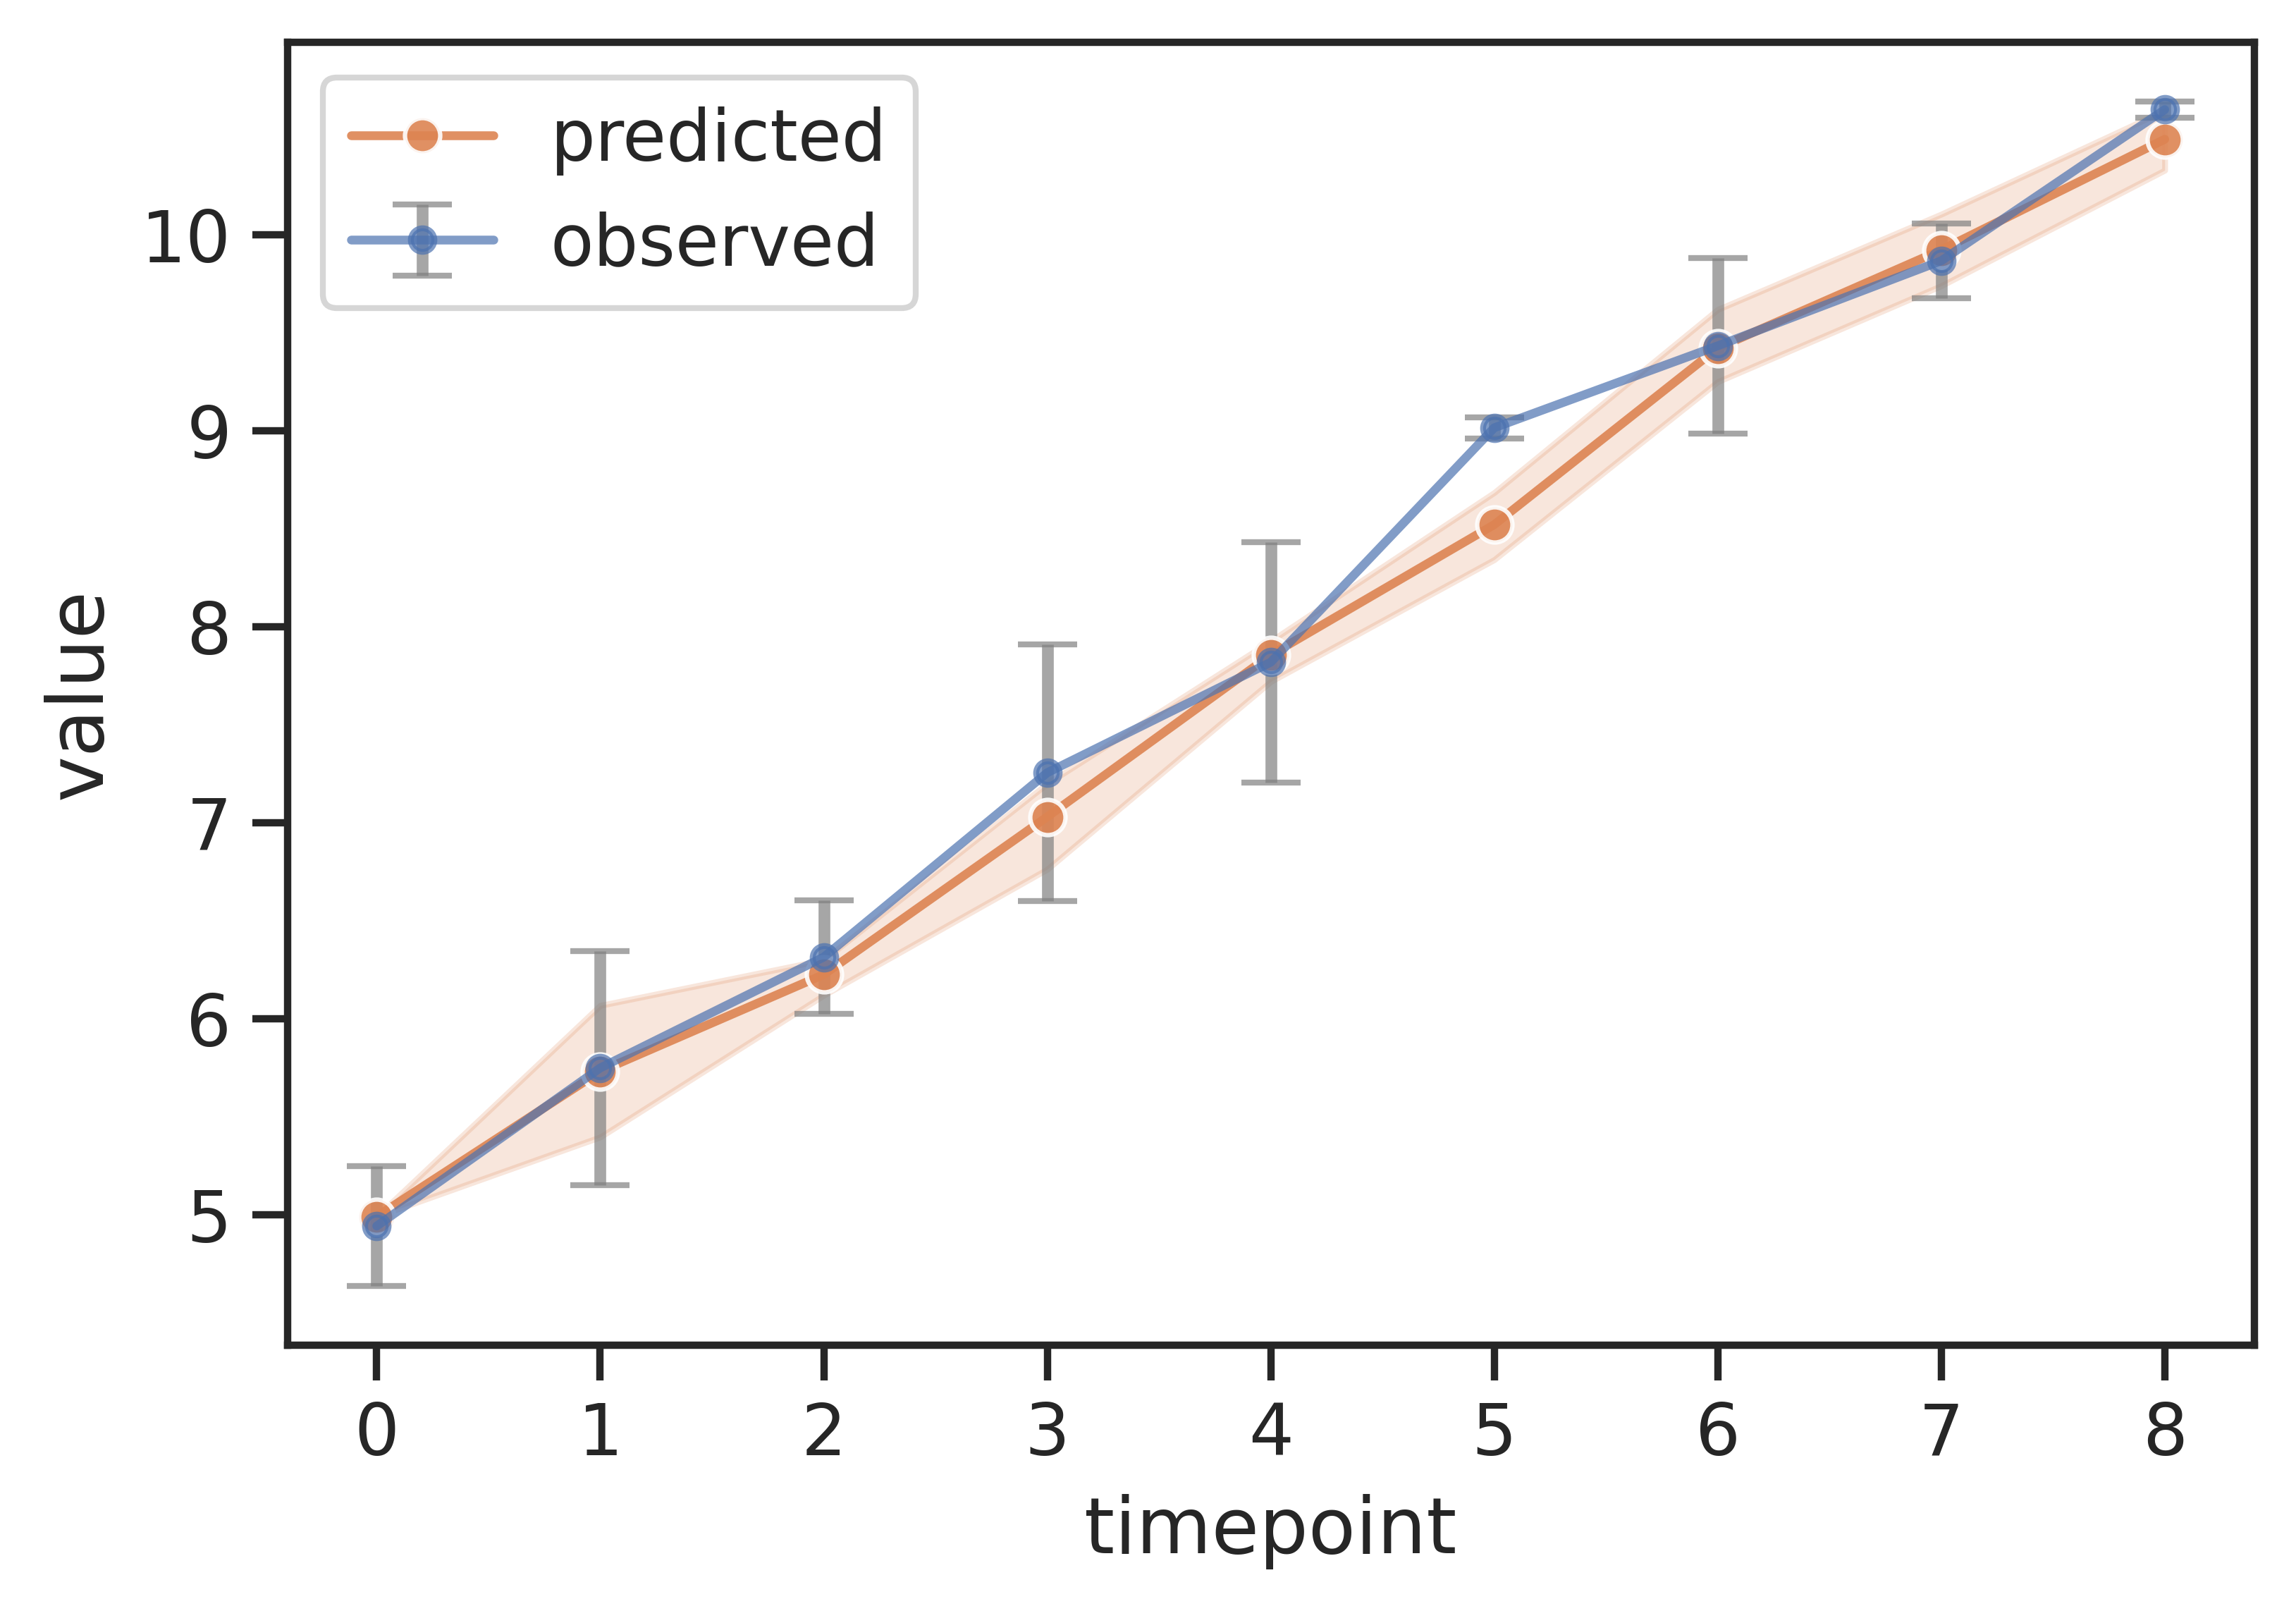

In [22]:
# Plot the line with error bars
sns.set_theme(style='ticks', font_scale=1.1)
fig = plt.figure(dpi=600, figsize=(6,4))
ax = fig.gca()


ax.errorbar(
    # x=adata.uns['pop']['t'],
    x=np.arange(9),
    y=log_mean,
    yerr=log_std,
    fmt='-o',          # Line and circle markers
    capsize=5,         # Error bar cap width
    ecolor='grey',      # Error bar color
    elinewidth=2,      # Error bar line width
    markersize=4,      # Marker size
    label='observed',
    alpha=0.7
)


sns.lineplot(data=sim_N_melt_df, x='timepoint', y='value', marker='o', ax=ax, label='predicted', alpha=0.9)
sns.lineplot(data=cell_seq, x='order', y='value', marker='o', ax=ax, label='sequenced', alpha=0.9)

ax.legend()

ax.set_xticks(np.arange(9))
ax.set_xticklabels(adata.uns['pop']['t'])
ax.set_ylabel('log population size')
ax.set_xlabel('timepoint')
sns.despine(ax=ax)

In [ ]:
fig.savefig('figures/fig4_population_size.pdf', format='pdf',transparent=True)

# plot density 

In [ ]:
timepoint_mask = [5,7]

In [ ]:
adata.obs['sim_u_D161'] =  np.log(u_int[5] +1e-20)
adata.obs['sim_u_D161'] = np.log(u_int[7] +1e-20)


In [ ]:
D76_df = adata.obs.query("`timepoint_tx_days` == 76").query("`fine_anno` != 'Eos'") # adata.obs.query("`fine_anno` != 'Eos'")
D76_df = D76_df[['obs_u_D76',  'sim_u_D76', 'fine_anno']].melt(id_vars=['fine_anno'])
D76_df['value source'] =  D76_df['variable'].map(
    {'obs_u_D76':'observed', 'sim_u_D76':'predicted'}
)
D76_df = D76_df.astype({"fine_anno":"object"})

D161_df = adata.obs.query("`timepoint_tx_days` == 161").query("`fine_anno` != 'Eos'") #adata.obs.query("`fine_anno` != 'Eos'")
D161_df = D161_df[['obs_u_D161',  'sim_u_D161', 'fine_anno']].melt(id_vars=['fine_anno'])
D161_df['value source'] =  D161_df['variable'].map(
    {'obs_u_D161':'observed', 'sim_u_D161':'predicted'}
)
D161_df = D161_df.astype({"fine_anno":"object"})

In [ ]:
cm_celltype = dict(zip(adata.obs.fine_anno.cat.categories, adata.uns['fine_anno_colors']))

In [ ]:
cm_celltype.keys()

dict_keys(['HSC', 'Int prog', 'Meg/Ery prog', 'Meg prog', 'Ery prog', 'Bas/MC prog', 'Eos prog', 'Mono/DC prog', 'Neu prog', 'Ly'])

In [ ]:
X_order = ['HSC', 'Int prog', 'Meg/Ery prog', 'Meg prog', 'Ery prog', 'Bas/MC prog', 'Mono/DC prog', 'Neu prog', 'Ly']

/tmp/ipykernel_2334869/1989228015.py:15: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for bars, hatch, legend_handle in zip(axs.containers, ['', '//'], axs.legend_.legendHandles):


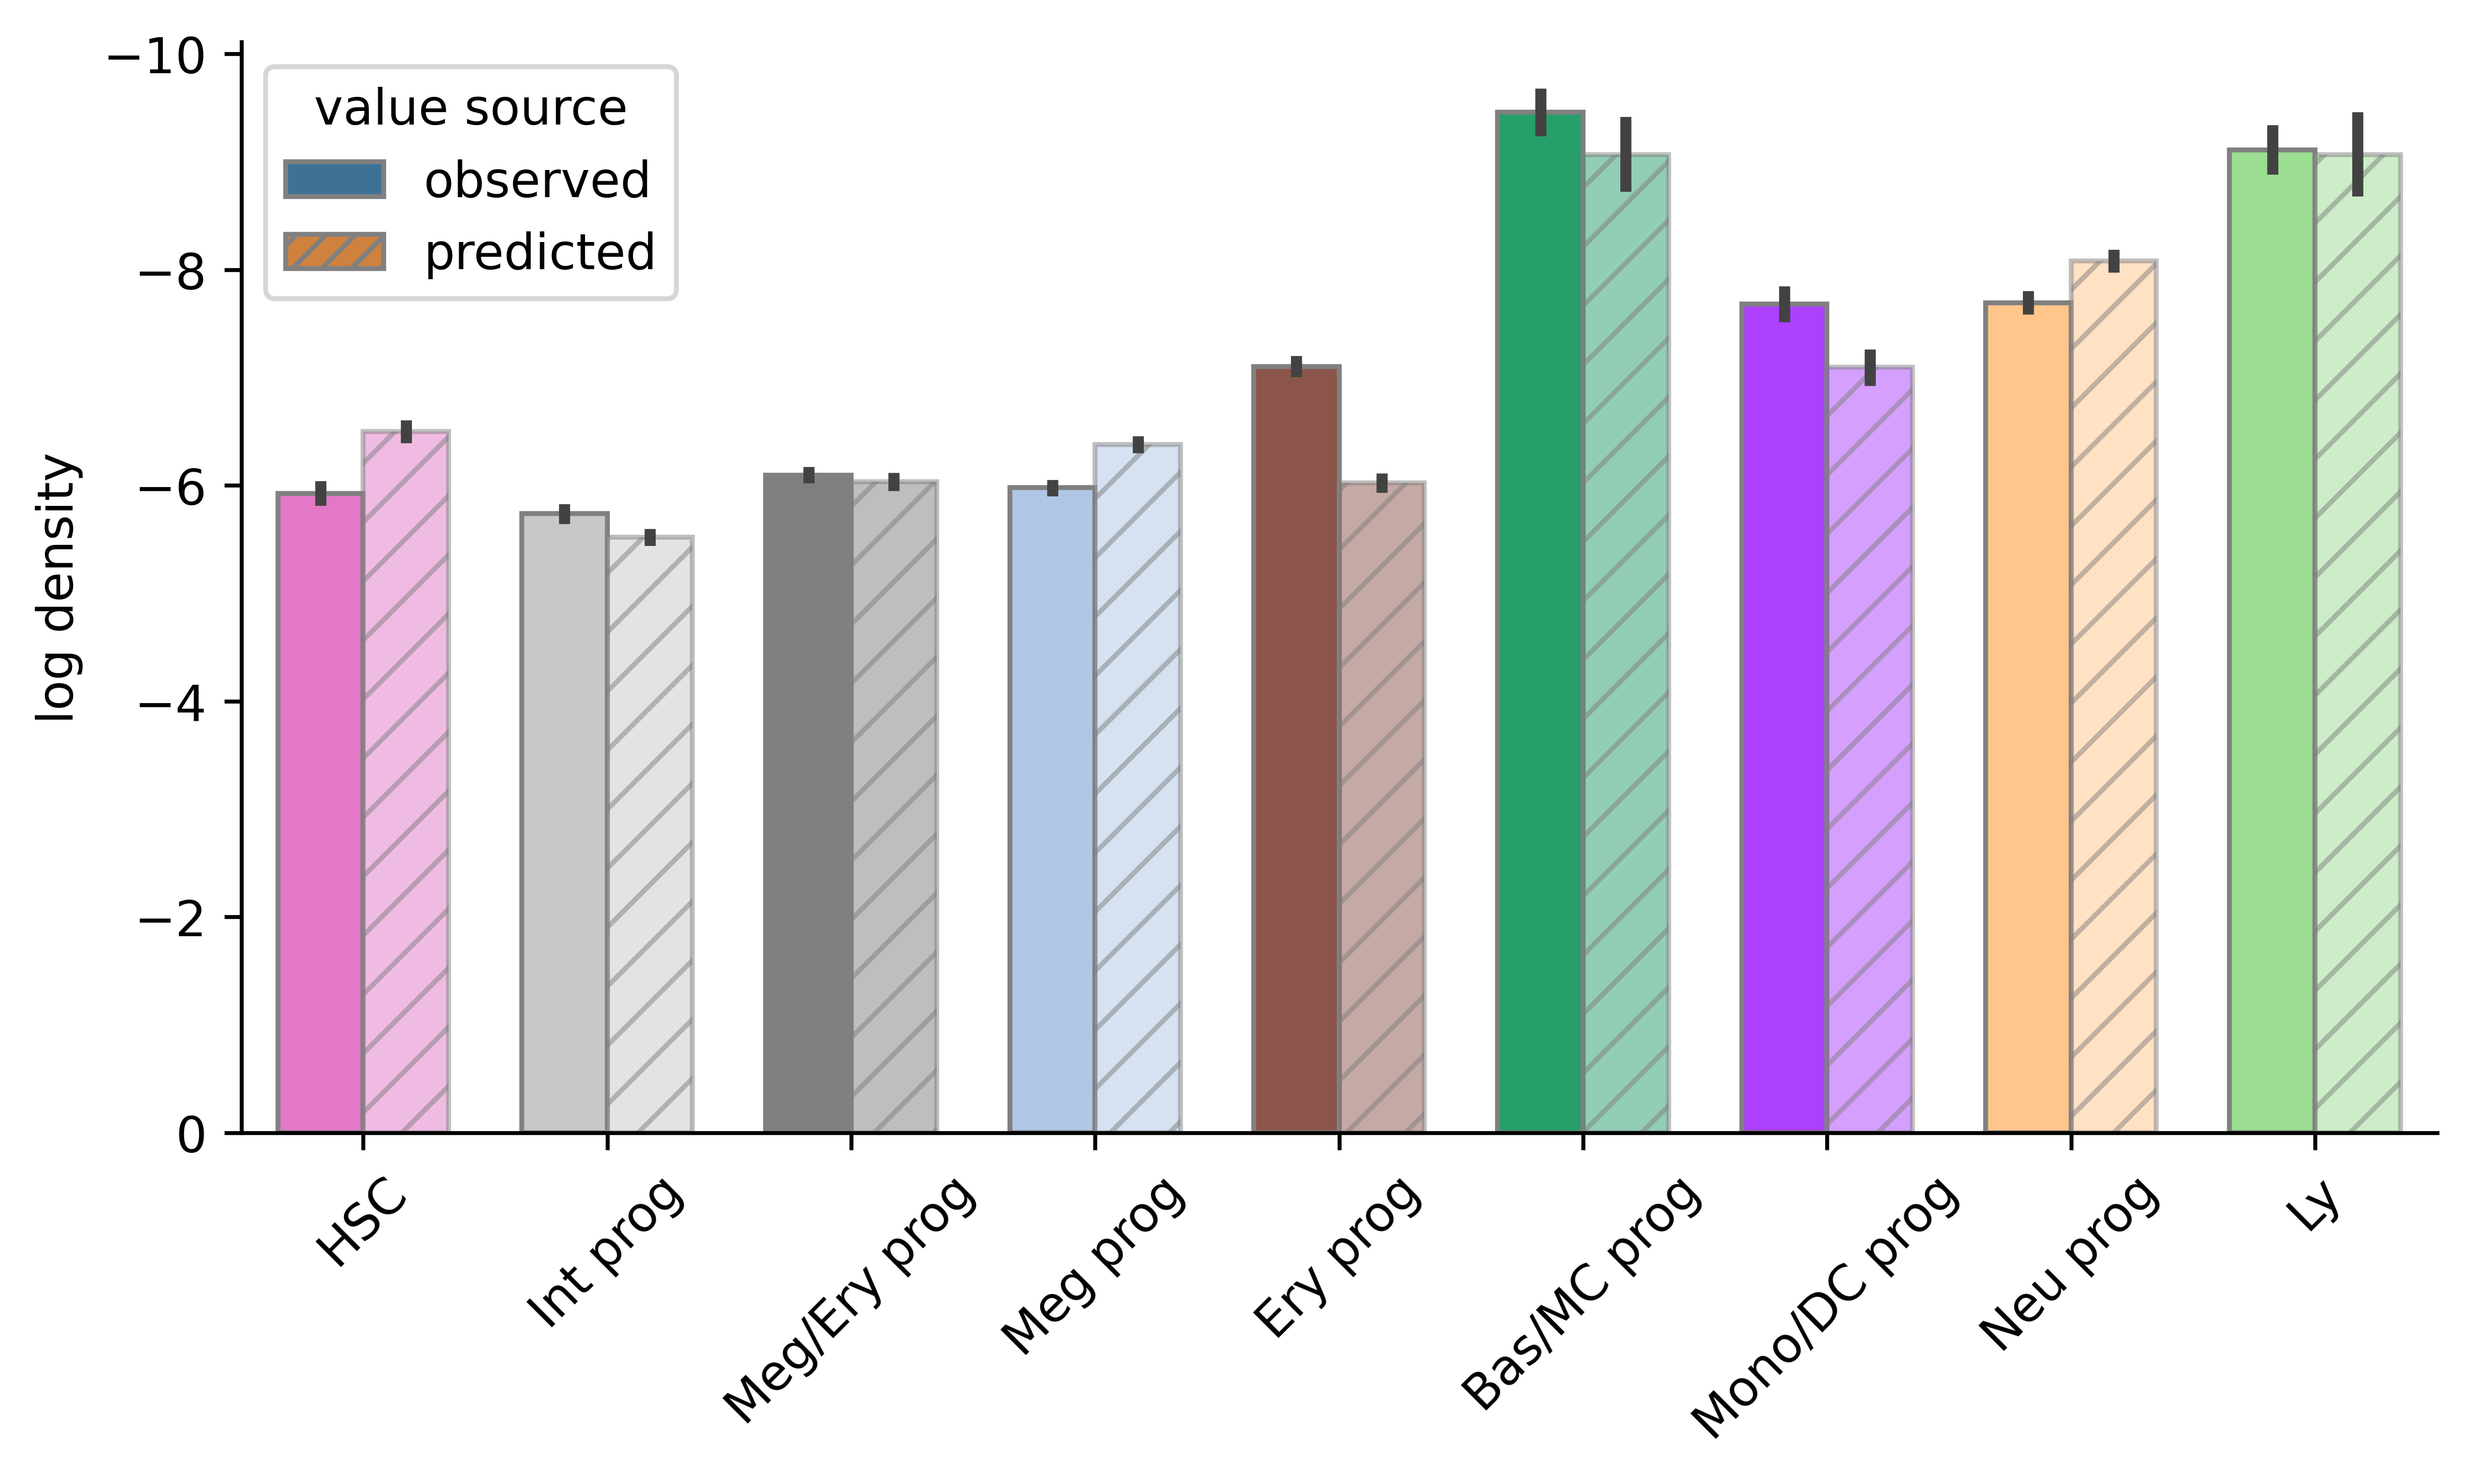

In [ ]:
fig = plt.figure(figsize=(8,4), dpi=600)


axs = sns.barplot(data=df, x='fine_anno', y='value',
                hue='value source', edgecolor='gray', width=0.7,
                saturation=0.6,
                order = X_order
                )

axs.invert_yaxis() 
axs.set_xlabel('')
axs.tick_params(axis='x', rotation=45)
axs.set_ylabel('log density')

for bars, hatch, legend_handle in zip(axs.containers, ['', '//'], axs.legend_.legendHandles):
    for bar, color in zip(bars, cm_celltype.values()):
        alpha = 1 if hatch == '' else 0.5
        bar.set_alpha(alpha)
        bar.set_facecolor(color)
        bar.set_hatch(hatch)
    # update the existing legend, use twice the hatching pattern to make it denser
    legend_handle.set_hatch(hatch + hatch)

sns.despine(ax=axs)

/tmp/ipykernel_2334869/418306822.py:15: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for bars, hatch, legend_handle in zip(axs[idx].containers, ['', '//'], axs[idx].legend_.legendHandles):
/tmp/ipykernel_2334869/418306822.py:15: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for bars, hatch, legend_handle in zip(axs[idx].containers, ['', '//'], axs[idx].legend_.legendHandles):


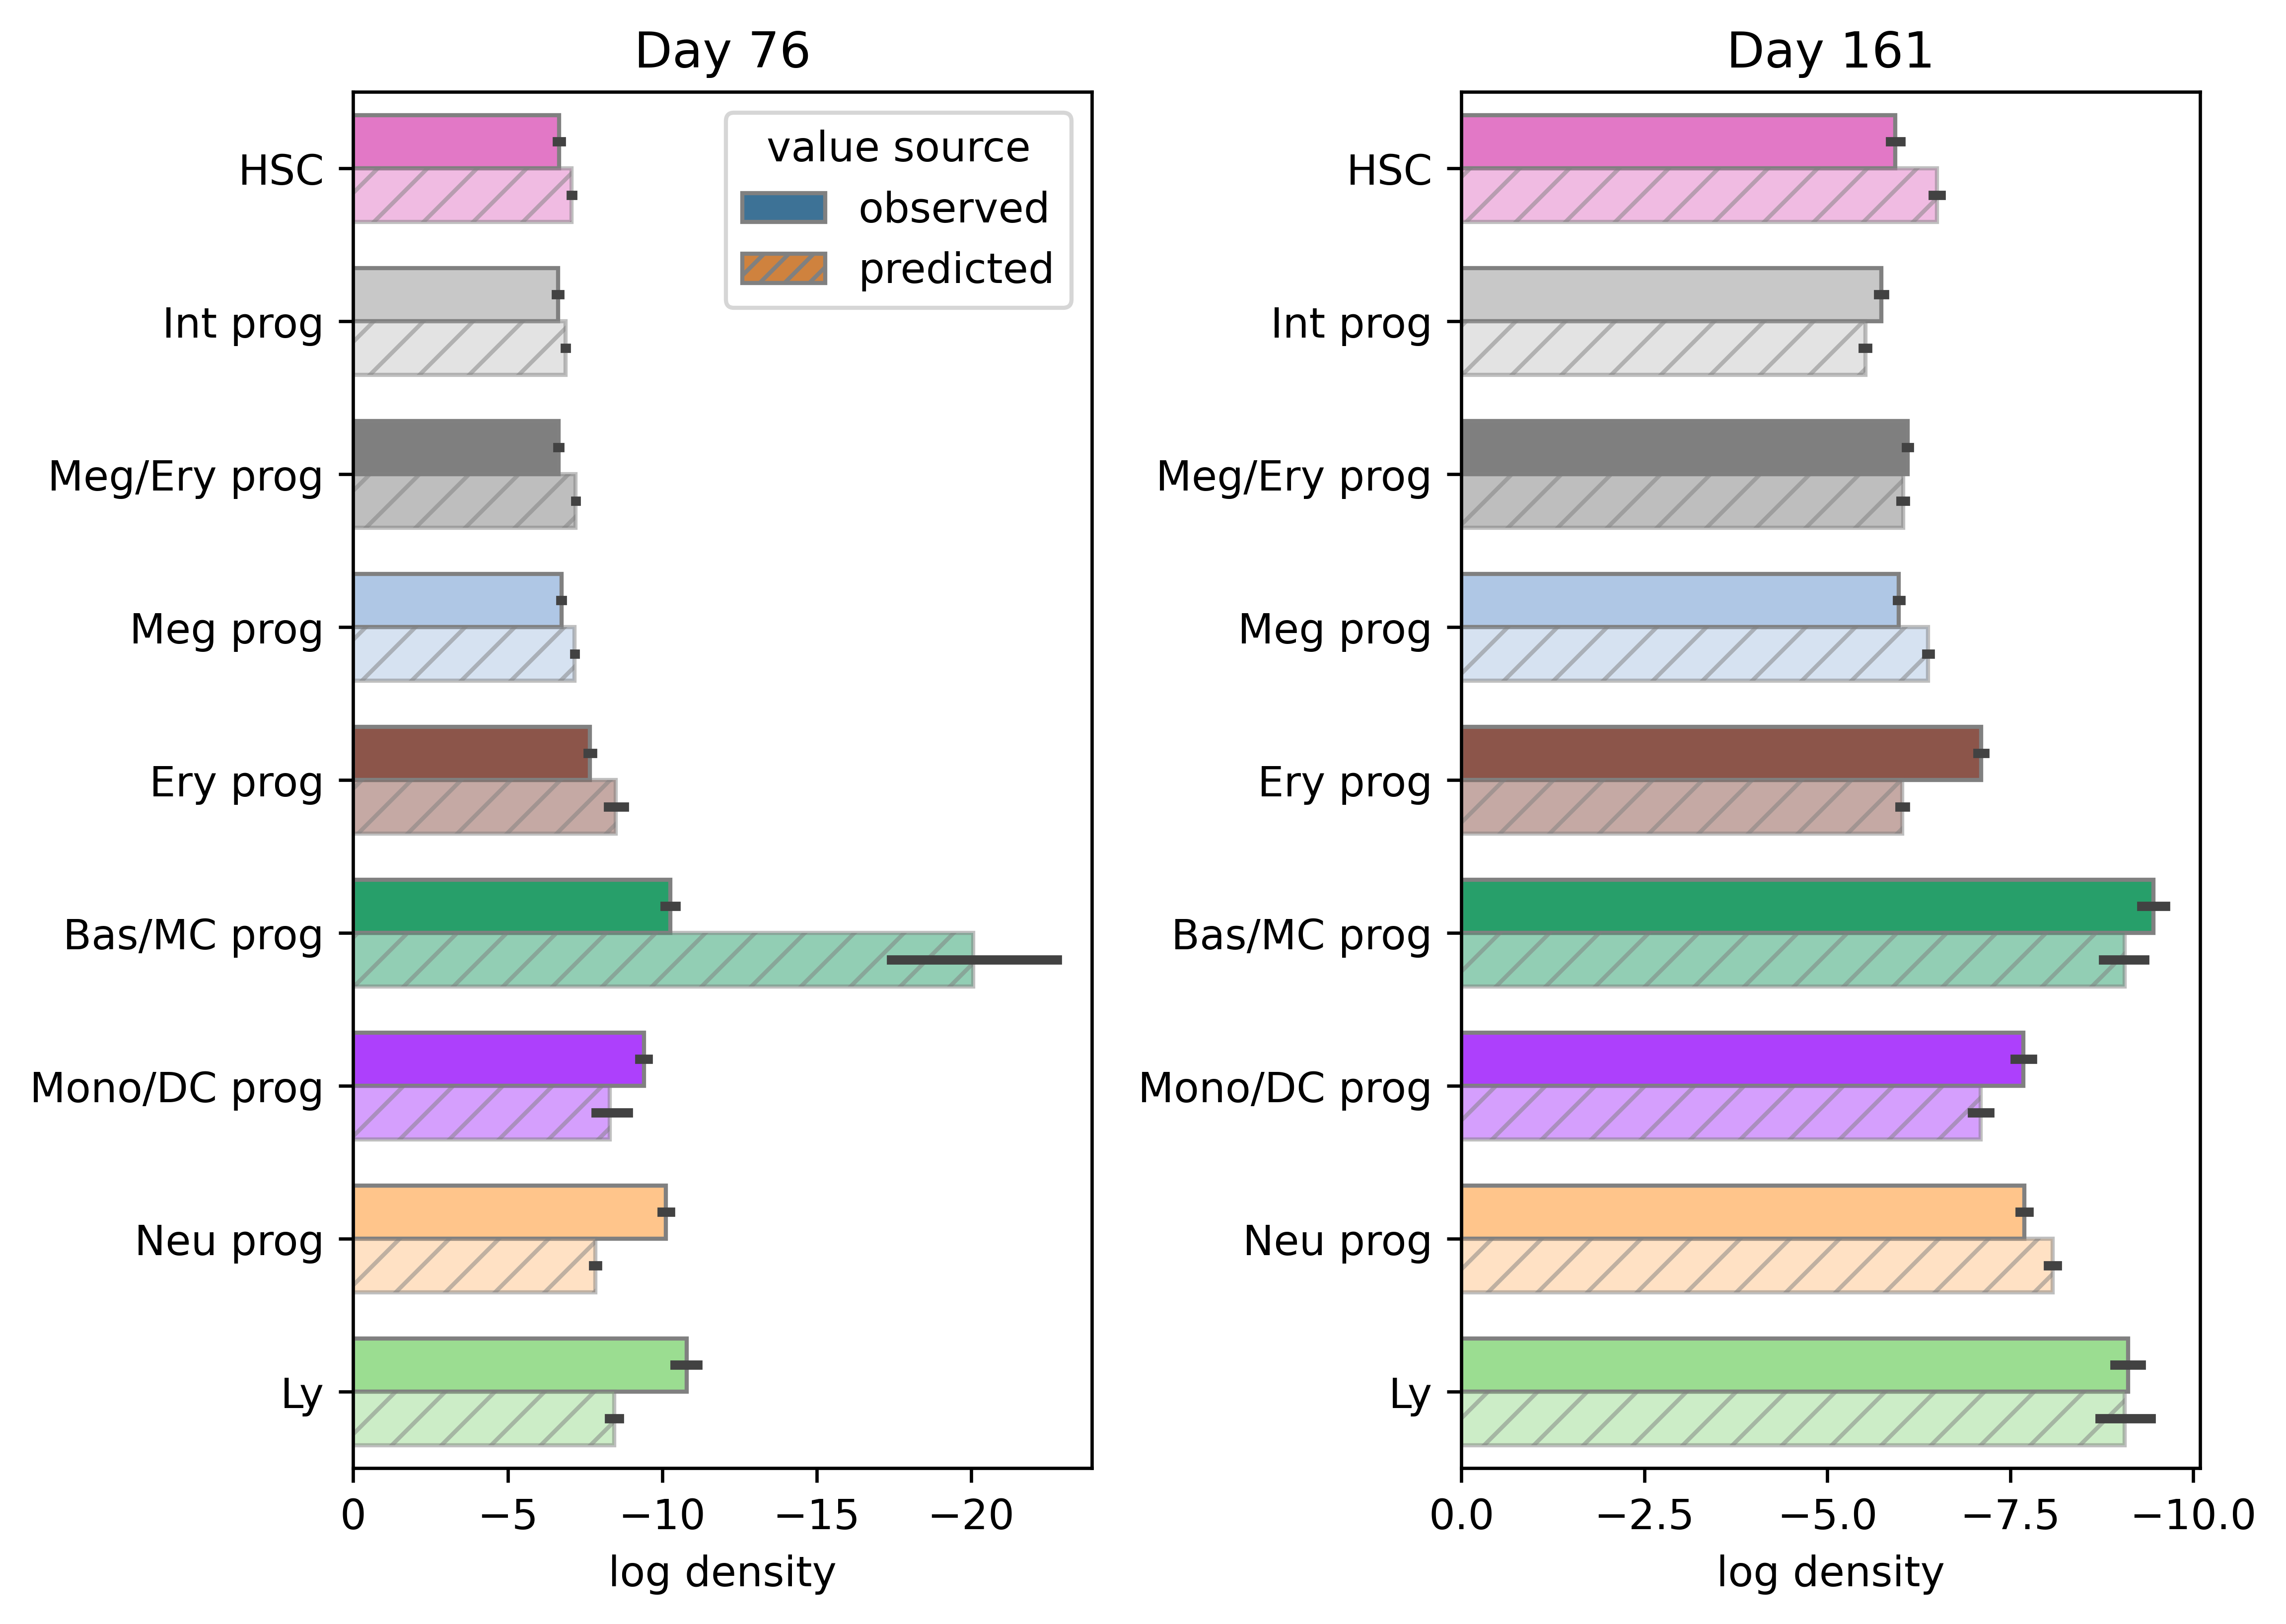

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(8,6), dpi=600, gridspec_kw={'wspace':0.5})

for idx, df in enumerate([D76_df, D161_df]):

    sns.barplot(data=df, y='fine_anno', x='value',
                    hue='value source', edgecolor='gray', width=0.7,
                    saturation=0.6, ax=axs[idx],
                    order = X_order
                    )

    axs[idx].invert_xaxis() 
    axs[idx].set_ylabel('')
    axs[idx].set_xlabel('log density')

    for bars, hatch, legend_handle in zip(axs[idx].containers, ['', '//'], axs[idx].legend_.legendHandles):
        for bar, color in zip(bars, cm_celltype.values()):
            alpha = 1 if hatch == '' else 0.5
            bar.set_alpha(alpha)
            bar.set_facecolor(color)
            bar.set_hatch(hatch)
        # update the existing legend, use twice the hatching pattern to make it denser
        legend_handle.set_hatch(hatch + hatch)

axs[0].set_title("Day 76")
axs[1].set_title("Day 161")
axs[1].legend([], frameon=False)
# axs[1].legend([], frameon=False)